In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [4]:
# Load
df = pd.read_csv(r"C:\Users\MOHINI\Downloads\European_Bank (1).csv")



In [5]:
# ── Basic Inspection ──────────────────────────────────────
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nDtypes:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())



Shape: (10000, 14)

Columns:
 ['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']

Dtypes:
 Year                 int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

Missing Values:
 Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

Duplicates: 0


In [6]:
# ── Validate Binary Columns ───────────────────────────────
binary_cols = ['HasCrCard', 'IsActiveMember', 'Exited']
for col in binary_cols:
    unique_vals = df[col].unique()
    print(f"{col} unique values: {unique_vals}")
    assert set(unique_vals).issubset({0, 1}), f"ERROR: {col} has unexpected values!"

print("\n✅ All binary columns validated.")



HasCrCard unique values: [1 0]
IsActiveMember unique values: [1 0]
Exited unique values: [1 0]

✅ All binary columns validated.


In [7]:
# ── Basic Stats ───────────────────────────────────────────
print("\nDescriptive Stats:")
df.describe()


Descriptive Stats:


,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
# ── Engagement Profile Assignment ─────────────────────────
def classify_engagement(row):
    active = row['IsActiveMember'] == 1
    multi_product = row['NumOfProducts'] > 1
    high_balance = row['Balance'] > df['Balance'].median()

    if active and multi_product:
        return 'Active Engaged'
    elif active and not multi_product:
        return 'Active Low-Product'
    elif not active and high_balance:
        return 'Inactive High-Balance'
    else:
        return 'Inactive Disengaged'

df['EngagementProfile'] = df.apply(classify_engagement, axis=1)



In [9]:
# ── Distribution Check ────────────────────────────────────
print(df['EngagementProfile'].value_counts())



EngagementProfile
Active Engaged           2588
Active Low-Product       2563
Inactive High-Balance    2456
Inactive Disengaged      2393
Name: count, dtype: int64


       EngagementProfile  ChurnRate
0         Active Engaged       9.66
1     Active Low-Product      18.92
2    Inactive Disengaged      21.23
3  Inactive High-Balance      32.33


C:\Users\MOHINI\AppData\Local\Temp\ipykernel_8872\1020340720.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=churn_by_engagement, x='EngagementProfile', y='ChurnRate', palette='Reds_r')


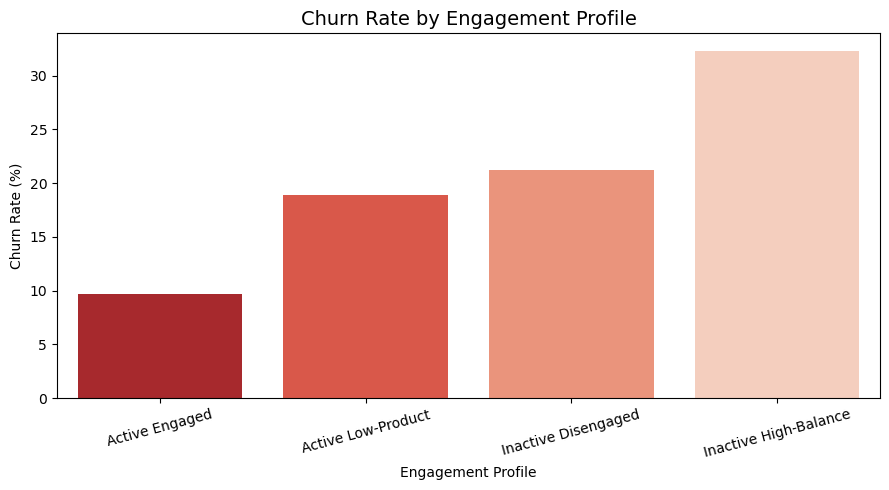

In [10]:
# ── Churn Rate by Engagement Profile ─────────────────────
churn_by_engagement = df.groupby('EngagementProfile')['Exited'].mean().reset_index()
churn_by_engagement.columns = ['EngagementProfile', 'ChurnRate']
churn_by_engagement['ChurnRate'] = (churn_by_engagement['ChurnRate'] * 100).round(2)
print(churn_by_engagement)
# ── Plot ──────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
sns.barplot(data=churn_by_engagement, x='EngagementProfile', y='ChurnRate', palette='Reds_r')
plt.title('Churn Rate by Engagement Profile', fontsize=14)
plt.ylabel('Churn Rate (%)')
plt.xlabel('Engagement Profile')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('churn_by_engagement.png', dpi=150)
plt.show()
